# Data Reading and Initial Setup

In [53]:
import json
import pandas as pd

# Load both datasets
with open('dataCollection/data/modern.json') as f:
    modern_data = json.load(f)

with open('dataCollection/data/legacy.json') as f:
    legacy_data = json.load(f)

def build_table(videos, label):
    rows = []
    for v in videos:
        rows.append({
            'Title': v['title'],
            'Upload Date': pd.to_datetime(v['publishedAt']).year,
            'Comment Count': len(v['comments']),
            'Category': label
        })
    return rows

rows = build_table(modern_data['videos'], 'Modern') + build_table(legacy_data['videos'], 'Legacy')
df = pd.DataFrame(rows).sort_values('Upload Date', ascending=False).reset_index(drop=True)
df

,Title,Upload Date,Comment Count,Category
0,Why Things Are Suddenly Looking Up for Ukraine,2026-04-25,935,Modern
1,Why Trump is selling out Ukraine for peace with Russia,2025-03-22,1000,Modern
2,Russia declares six US missiles fired by Ukraine,2024-11-19,1000,Legacy
3,Fury in Russia at 'serious escalation' of Ukraine missile move | BBC News,2024-11-18,1000,Legacy
4,Trump's Ukraine Peace Plan Explained,2024-11-09,1000,Modern
5,Ukraine 'seizes more Russian territory' in biggest incursion since WW2 | BBC...,2024-08-14,1000,Legacy
6,‘Putin warned you’: Sky News host claims Russia-Ukraine war is ‘NATO’s war’,2024-04-28,1000,Legacy
7,Ukraine strikes targets over 1200 kilometers into Russian territory | DW News,2024-04-02,688,Legacy
8,Putin threatens nuclear war if the West sends troops to Ukraine I DW News,2024-02-29,1000,Legacy
9,"After Kherson, Where Will Ukraine Go Next?",2022-11-15,1000,Modern


In [23]:
import json
import re
import nltk
from datetime import datetime, timezone
from collections import Counter
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import detect, LangDetectException
from resources.abbreviations import ABBREVIATIONS

abbrev_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in ABBREVIATIONS.keys()) + r')\b'
)
stop_words = set(stopwords.words('english'))

def load_comments(filepath):
    """Load English comments from a YouTube JSON file."""
    comments = []
    skipped_non_english = 0
    skipped_empty = 0

    with open(filepath) as f:
        data = json.load(f)

    for video in data["videos"]:
        for comment in video.get("comments", []):
            text = comment.get("text", "").strip()
            if not text:
                skipped_empty += 1
                continue
            try:
                if detect(text) != 'en':
                    skipped_non_english += 1
                    continue
            except LangDetectException:
                skipped_non_english += 1
                continue

            comments.append({
                "author": comment["author"],
                "raw_text": text,
                "text": text.lower(),
                "publishedAt": comment["publishedAt"],
                "likeCount": comment["likeCount"],
                "videoTitle": video["title"],
                "channelTitle": video.get("channelTitle", ""),
            })

    print(f"{filepath}: {len(comments)} kept, {skipped_non_english} non-English, {skipped_empty} empty")
    return comments

legacy_comments = load_comments("dataCollection/data/legacy.json")
modern_comments = load_comments("dataCollection/data/modern.json")

dataCollection/data/legacy.json: 14567 kept, 2175 non-English, 2 empty
dataCollection/data/modern.json: 12518 kept, 1702 non-English, 0 empty


## Number of Unique Commenters

In [24]:
def commenter_stats(comments, label):
    authors = [c["author"] for c in comments]
    total = len(authors)
    unique = len(set(authors))
    print(f"{label}")
    print(f"  Total comments:    {total}")
    print(f"  Unique commenters: {unique}")
    return set(authors)

legacy_authors  = commenter_stats(legacy_comments,  "Legacy")
modern_authors  = commenter_stats(modern_comments,  "Modern")

all_comments = legacy_comments + modern_comments
all_authors  = legacy_authors | modern_authors
total        = len(all_comments)
unique       = len(all_authors)
print(f"Combined")
print(f"  Total comments:    {total}")
print(f"  Unique commenters: {unique}")
print(f"  Overlap (on both): {len(legacy_authors & modern_authors)}")

Legacy
  Total comments:    14567
  Unique commenters: 13212
Modern
  Total comments:    12518
  Unique commenters: 11562
Combined
  Total comments:    27085
  Unique commenters: 24373
  Overlap (on both): 401


## Timeline of comments

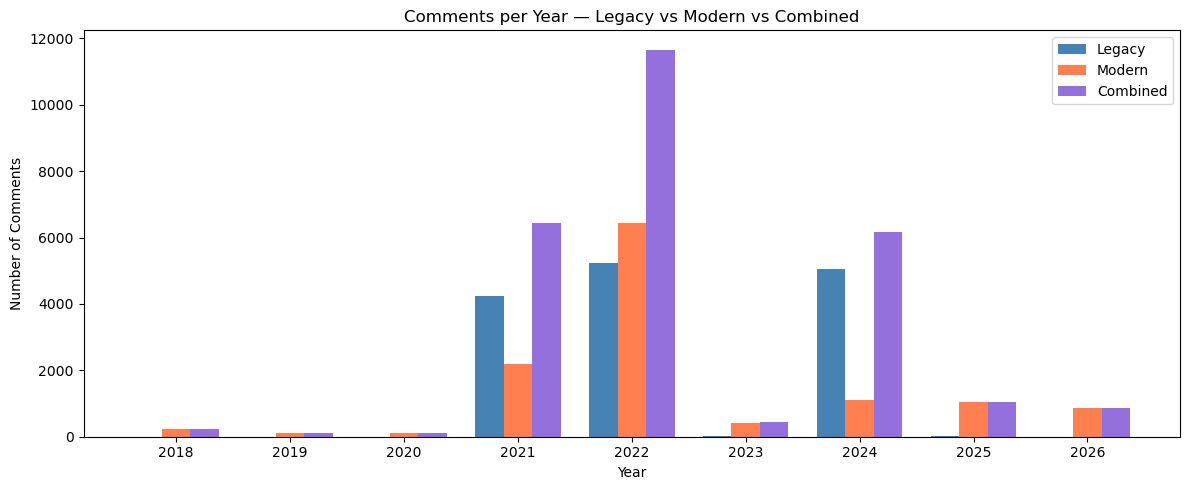

In [25]:
from collections import defaultdict
import matplotlib.pyplot as plt

def comments_by_year(comments):
    counts = defaultdict(int)
    for c in comments:
        year = datetime.fromisoformat(c["publishedAt"].replace("Z", "+00:00")).year
        counts[year] += 1
    return counts

legacy_by_year  = comments_by_year(legacy_comments)
modern_by_year  = comments_by_year(modern_comments)

all_years = sorted(set(legacy_by_year) | set(modern_by_year))

legacy_vals   = [legacy_by_year.get(y, 0)  for y in all_years]
modern_vals   = [modern_by_year.get(y, 0)  for y in all_years]
combined_vals = [l + m for l, m in zip(legacy_vals, modern_vals)]

x = range(len(all_years))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width for i in x], legacy_vals,   width=width, label="Legacy",   color="steelblue")
ax.bar([i          for i in x], modern_vals,   width=width, label="Modern",   color="coral")
ax.bar([i + width  for i in x], combined_vals, width=width, label="Combined", color="mediumpurple")

ax.set_xticks(list(x))
ax.set_xticklabels(all_years)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Comments")
ax.set_title("Comments per Year — Legacy vs Modern vs Combined")
ax.legend()
plt.tight_layout()
plt.show()

### Counting Top 50 Words Before Preprocessing

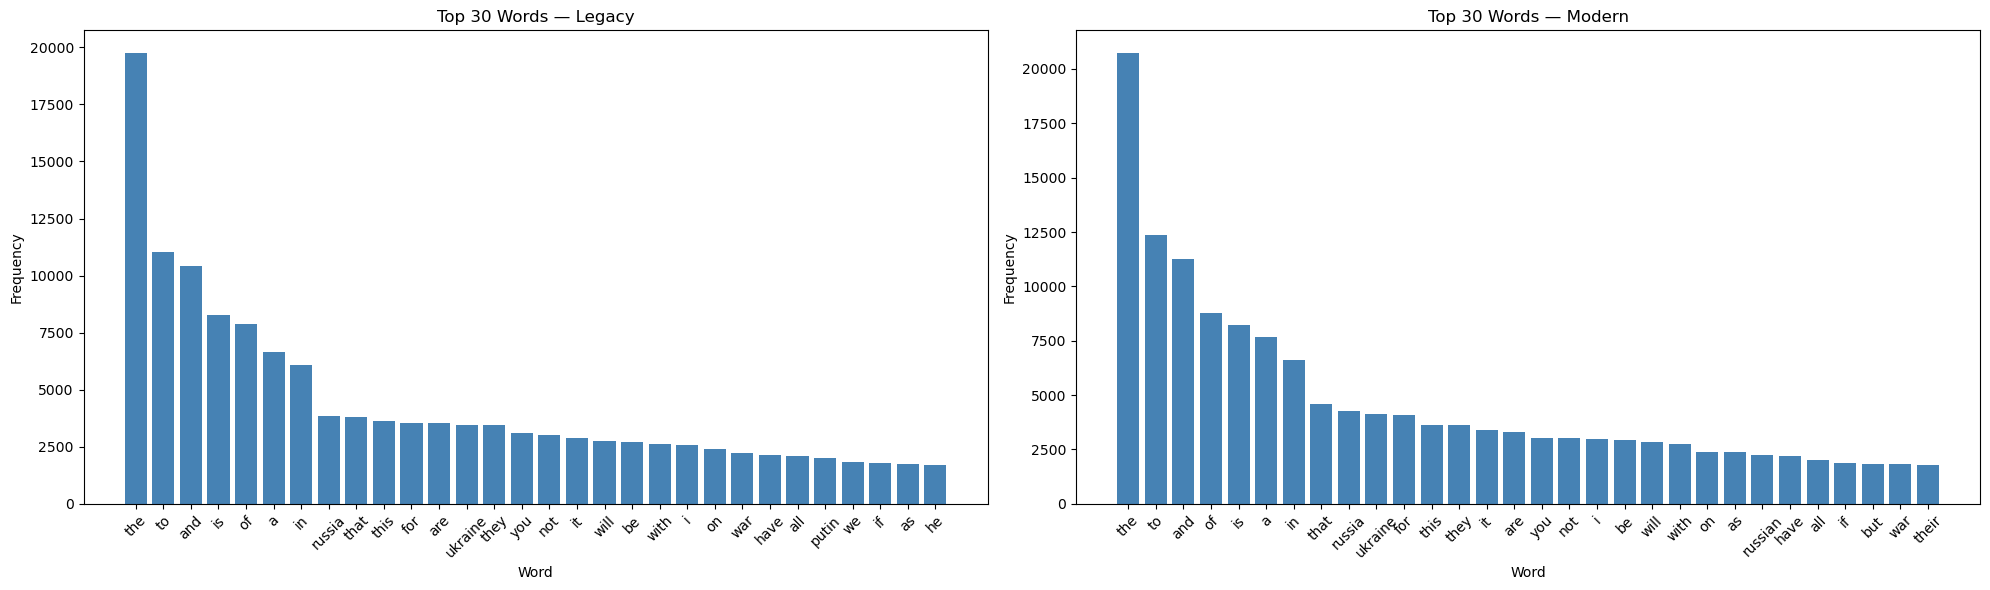

In [26]:
def plot_top_words(comments, label, ax, n=30):
    tokens = []
    for c in comments:
        tokens.extend(c["text"].split())
    top_n = Counter(tokens).most_common(n)
    words, counts = zip(*top_n)
    ax.bar(words, counts, color="steelblue")
    ax.set_title(f"Top {n} Words — {label}")
    ax.set_xlabel("Word")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plot_top_words(legacy_comments,  "Legacy", ax1)
plot_top_words(modern_comments, "Modern", ax2)
plt.tight_layout()
plt.show()

# Preprocessing
Preprocessing steps below include:
- Conversion to lowercase
- URL removal
- Abbreviations and acronyms replaced with natural language words
- Digits and fractions removed
- Tokenization into individual words
- Non-alphabetic tokens (punctuation, symbols) removed
- Stop words removed

In [27]:
def _preprocess_text(text):
    text = re.sub(r"https?://\S+", "", text)          # strip URLs
    text = abbrev_pattern.sub(lambda m: ABBREVIATIONS[m.group(0)], text)
    text = re.sub(r"\b\d+([./]\d+)?\b", "", text)
    tokens = nltk.word_tokenize(text)
    tokens = [t.strip() for t in tokens if t.strip().isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    return tokens


def preprocess_comments(comments):
    """Tokenize and clean comments in-place; prints a summary."""
    for c in comments:
        c["tokens"] = _preprocess_text(c["text"])
        c["text"] = " ".join(c["tokens"])
    print(f"Preprocessed {len(comments)} comments")

preprocess_comments(legacy_comments)
preprocess_comments(modern_comments)

Preprocessed 14567 comments
Preprocessed 12518 comments


### Counting Top 50 Words After Preprocessing

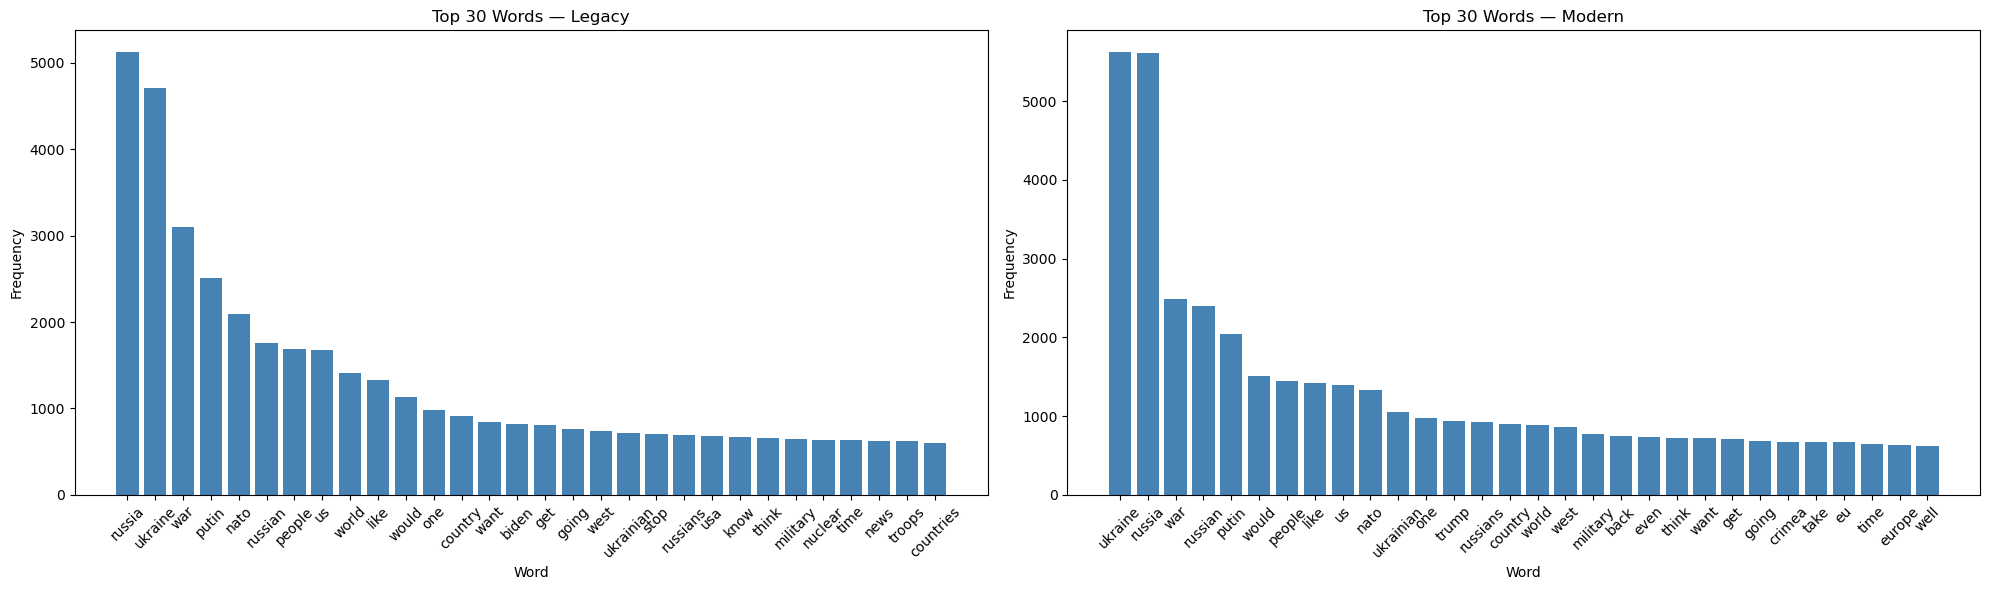

In [28]:
def plot_top_words(comments, label, ax, n=30):
    tokens = []
    for c in comments:
        tokens.extend(c["text"].split())
    top_n = Counter(tokens).most_common(n)
    words, counts = zip(*top_n)
    ax.bar(words, counts, color="steelblue")
    ax.set_title(f"Top {n} Words — {label}")
    ax.set_xlabel("Word")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plot_top_words(legacy_comments,  "Legacy", ax1)
plot_top_words(modern_comments, "Modern", ax2)
plt.tight_layout()
plt.show()

# Sentiment Analysis

In [29]:
def run_sentiment(comments):
    sia = SentimentIntensityAnalyzer()
    vader_labels = Counter()

    for c in comments:
        scores = sia.polarity_scores(c["raw_text"])
        c["vaderScores"] = scores
        c["vaderCompound"] = scores["compound"]
        if scores["compound"] >= 0.05:
            c["vaderLabel"] = "positive"
        elif scores["compound"] <= -0.05:
            c["vaderLabel"] = "negative"
        else:
            c["vaderLabel"] = "neutral"
        vader_labels[c["vaderLabel"]] += 1

    total = len(comments)
    return {
        "total": total,
        "vader": {k: {"n": v, "pct": v / total * 100} for k, v in vader_labels.items()},
        "vader_mean": sum(c["vaderCompound"] for c in comments) / total,
    }

legacy_summary = run_sentiment(legacy_comments)
modern_summary = run_sentiment(modern_comments)

## Sentiment Distribution Charts

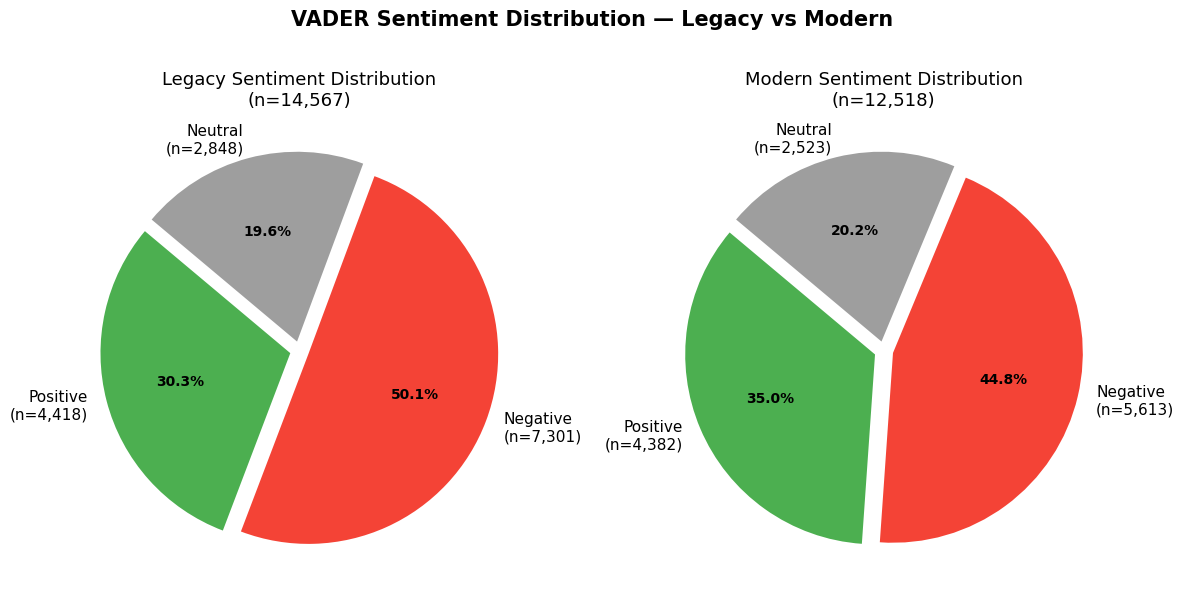

In [50]:
import matplotlib.pyplot as plt

def plot_sentiment_pies(legacy_summary, modern_summary):
    labels = ["positive", "negative", "neutral"]
    colors = {"positive": "#4CAF50", "negative": "#F44336", "neutral": "#9E9E9E"}
    explode = (0.05, 0.05, 0.05)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, summary, title in [
        (axes[0], legacy_summary, "Legacy"),
        (axes[1], modern_summary, "Modern"),
    ]:
        sizes = [summary["vader"].get(l, {"pct": 0})["pct"] for l in labels]
        counts = [summary["vader"].get(l, {"n": 0})["n"] for l in labels]
        pie_colors = [colors[l] for l in labels]

        wedges, texts, autotexts = ax.pie(
            sizes,
            labels=[f"{l.capitalize()}\n(n={c:,})" for l, c in zip(labels, counts)],
            autopct="%1.1f%%",
            colors=pie_colors,
            explode=explode,
            startangle=140,
            textprops={"fontsize": 11},
        )
        for at in autotexts:
            at.set_fontsize(10)
            at.set_fontweight("bold")

        ax.set_title(f"{title} Sentiment Distribution\n(n={summary['total']:,})", fontsize=13)

    plt.suptitle("VADER Sentiment Distribution — Legacy vs Modern", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_sentiment_pies(legacy_summary, modern_summary)
#ADD MEAN COMPOUND SCORE

## Word Clouds

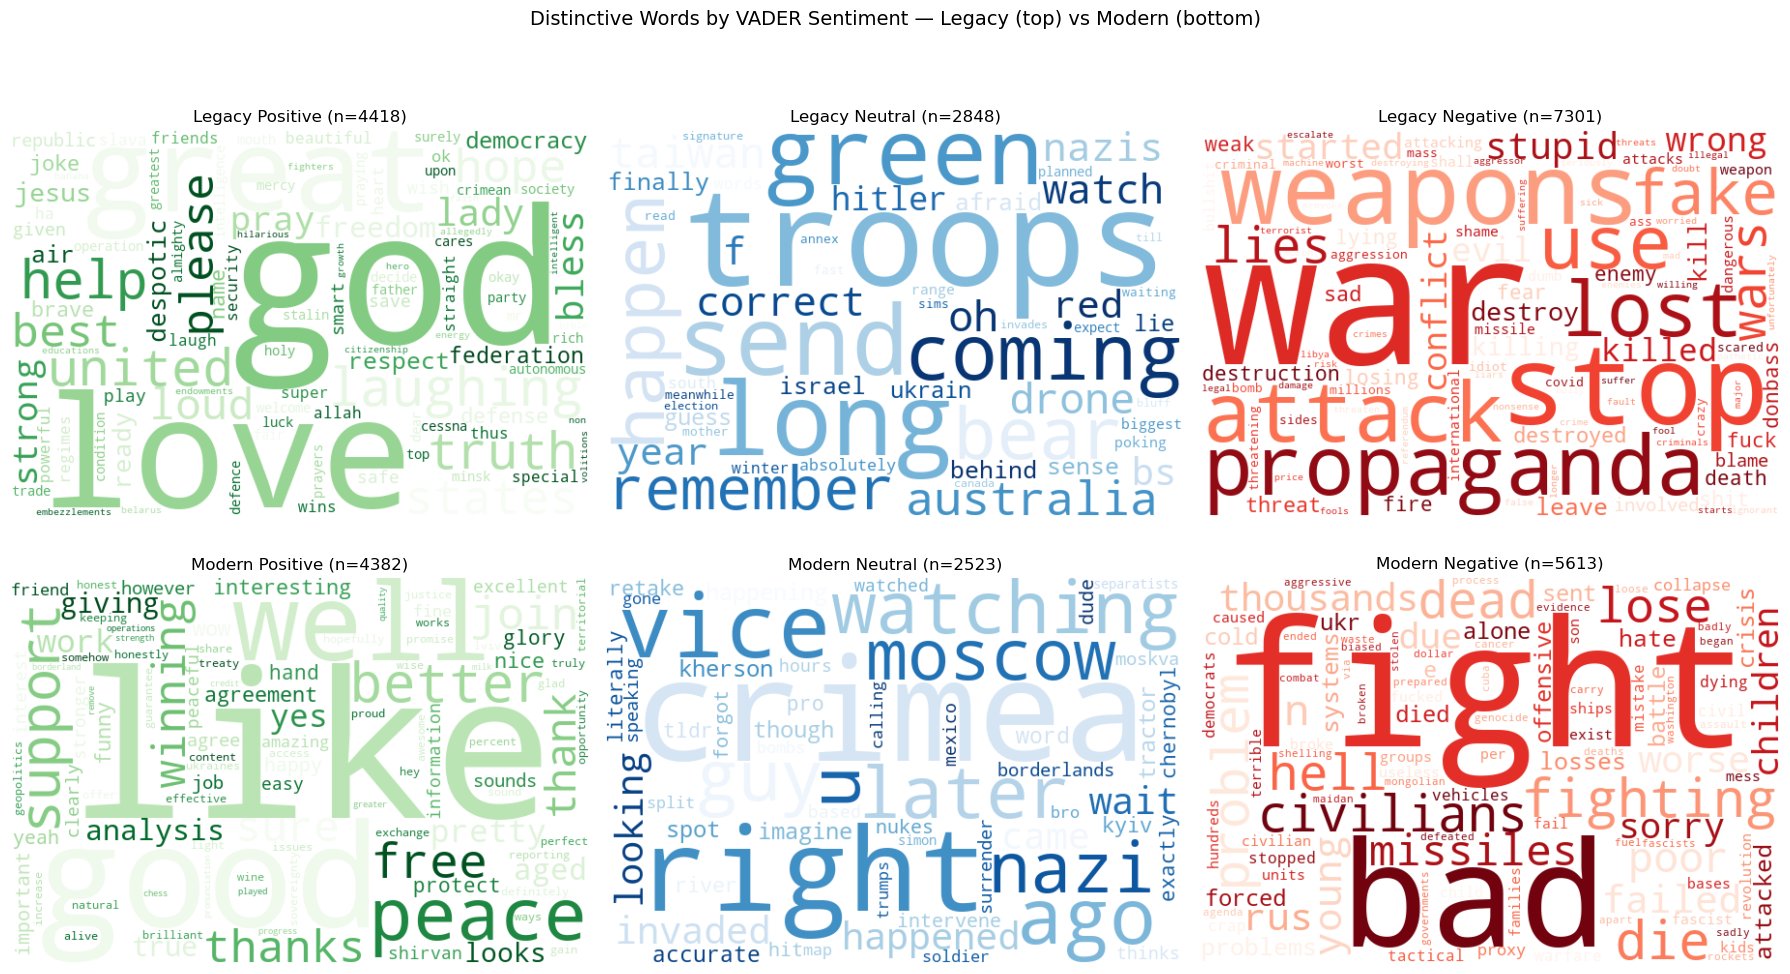

In [52]:
from wordcloud import WordCloud

def get_distinctive(comments_subset, all_comments, min_count=10):
    subset_ids = set(map(id, comments_subset))
    subset_freq = Counter(t for c in comments_subset for t in c['tokens'])
    rest_freq   = Counter(t for c in all_comments if id(c) not in subset_ids
                          for t in c['tokens'])
    total_sub  = sum(subset_freq.values()) or 1
    total_rest = sum(rest_freq.values()) or 1
    return {
        w: subset_freq[w]
        for w in subset_freq
        if subset_freq[w] >= min_count
        and subset_freq[w] / total_sub > 2 * (rest_freq.get(w, 0) / total_rest)
    }

def deduplicate_groups(freq_groups):
    result = {label: dict(freq) for label, freq in freq_groups.items()}
    for word in set(w for f in freq_groups.values() for w in f):
        best = max(freq_groups, key=lambda l: freq_groups[l].get(word, 0))
        for label in result:
            if label != best:
                result[label].pop(word, None)
    return result

# Legacy splits
l_pos = [c for c in legacy_comments if c['vaderCompound'] >= 0.05]
l_neu = [c for c in legacy_comments if -0.05 < c['vaderCompound'] < 0.05]
l_neg = [c for c in legacy_comments if c['vaderCompound'] <= -0.05]

# Modern splits
m_pos = [c for c in modern_comments if c['vaderCompound'] >= 0.05]
m_neu = [c for c in modern_comments if -0.05 < c['vaderCompound'] < 0.05]
m_neg = [c for c in modern_comments if c['vaderCompound'] <= -0.05]

groups = [
    (l_pos, legacy_comments, f'Legacy Positive (n={len(l_pos)})', 'Greens'),
    (l_neu, legacy_comments, f'Legacy Neutral (n={len(l_neu)})',  'Blues'),
    (l_neg, legacy_comments, f'Legacy Negative (n={len(l_neg)})', 'Reds'),
    (m_pos, modern_comments, f'Modern Positive (n={len(m_pos)})', 'Greens'),
    (m_neu, modern_comments, f'Modern Neutral (n={len(m_neu)})',  'Blues'),
    (m_neg, modern_comments, f'Modern Negative (n={len(m_neg)})', 'Reds'),
]

raw_freqs = {title: get_distinctive(subset, all_c) for subset, all_c, title, cmap in groups}
deduped   = deduplicate_groups(raw_freqs)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (subset, all_c, title, cmap) in zip(axes.flat, groups):
    freq = deduped[title]
    if freq:
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=cmap, max_words=100)
        wc.generate_from_frequencies(freq)
        ax.imshow(wc, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'Not enough\ndistinctive words',
                ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
    ax.set_title(title, fontsize=12)

plt.suptitle('Distinctive Words by VADER Sentiment — Legacy (top) vs Modern (bottom)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Sentiment Over Time

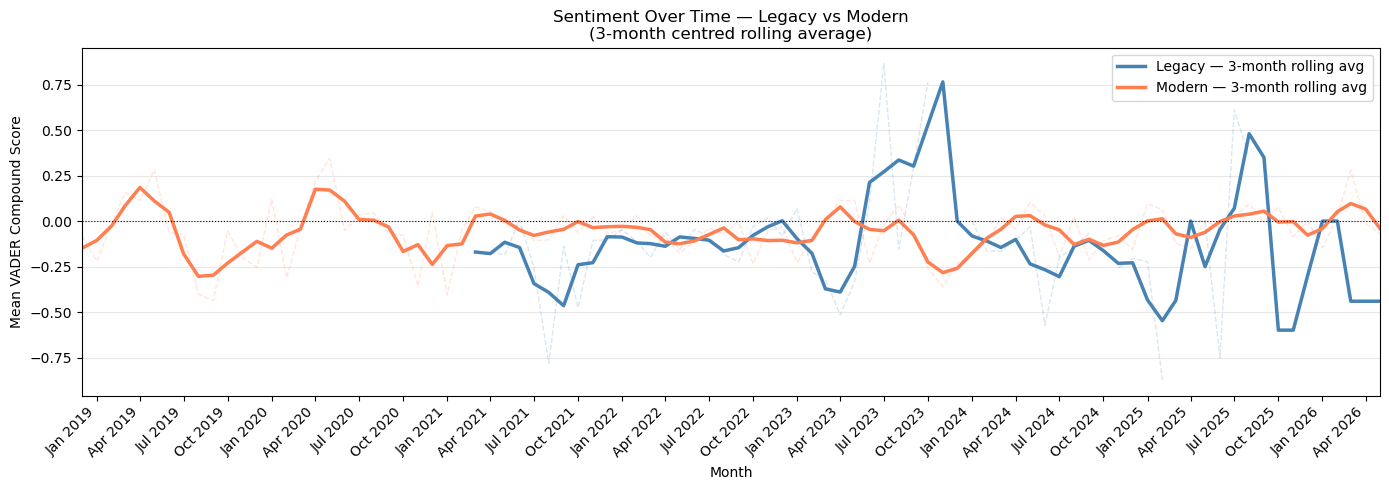

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Build monthly mean VADER compound score ---
def monthly_sentiment(comments, label):
    rows = [
        {
            "month": datetime.fromisoformat(c["publishedAt"].replace("Z", "+00:00"))
                             .replace(day=1, hour=0, minute=0, second=0, microsecond=0,
                                      tzinfo=None),
            "compound": c["vaderCompound"],
        }
        for c in comments
    ]
    df = pd.DataFrame(rows)
    return df.groupby("month")["compound"].mean().rename(label)

legacy_monthly = monthly_sentiment(legacy_comments, "Legacy")
modern_monthly = monthly_sentiment(modern_comments, "Modern")

# Align on the same date index, compute 3-month centred rolling average
combined = pd.concat([legacy_monthly, modern_monthly], axis=1).sort_index()
rolling  = combined.rolling(window=3, min_periods=1, center=True).mean()


fig, ax = plt.subplots(figsize=(14, 5))

# Rolling averages (bold)
ax.plot(rolling.index, rolling["Legacy"], color="steelblue", linewidth=2.5, label="Legacy — 3-month rolling avg")
ax.plot(rolling.index, rolling["Modern"], color="coral",     linewidth=2.5, label="Modern — 3-month rolling avg")

# Raw monthly means (faint, for context)
ax.plot(combined.index, combined["Legacy"], color="steelblue", alpha=0.2, linewidth=1, linestyle="--")
ax.plot(combined.index, combined["Modern"], color="coral",     alpha=0.2, linewidth=1, linestyle="--")

# Neutral baseline
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

ax.set_xlim(combined.index.min(), combined.index.max())
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Month")
ax.set_ylabel("Mean VADER Compound Score")
ax.set_title("Sentiment Over Time — Legacy vs Modern\n(3-month centred rolling average)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Legacy  — plain mean: -0.1357  |  like-weighted mean: -0.1072
Modern  — plain mean: -0.0799  |  like-weighted mean: 0.0800


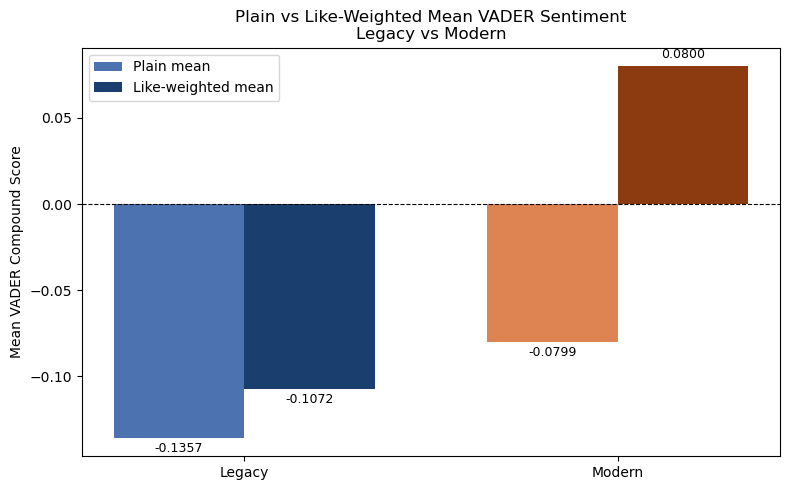

In [51]:
import matplotlib.pyplot as plt

def like_weighted_vader_mean(comments):
    """Weighted mean compound score, weighted by likeCount (likes=0 get weight 1)."""
    total_weight = 0
    weighted_sum = 0.0
    for c in comments:
        weight = max(c["likeCount"], 1)  # floor at 1 so unliked comments still count
        weighted_sum += c["vaderCompound"] * weight
        total_weight += weight
    return weighted_sum / total_weight

legacy_plain_mean    = legacy_summary["vader_mean"]
modern_plain_mean    = modern_summary["vader_mean"]
legacy_weighted_mean = like_weighted_vader_mean(legacy_comments)
modern_weighted_mean = like_weighted_vader_mean(modern_comments)

print(f"Legacy  — plain mean: {legacy_plain_mean:.4f}  |  like-weighted mean: {legacy_weighted_mean:.4f}")
print(f"Modern  — plain mean: {modern_plain_mean:.4f}  |  like-weighted mean: {modern_weighted_mean:.4f}")

# Chart
labels  = ["Legacy", "Modern"]
plain   = [legacy_plain_mean,    modern_plain_mean]
weighted = [legacy_weighted_mean, modern_weighted_mean]

x      = range(len(labels))
width  = 0.35
colors_plain    = ["#4C72B0", "#DD8452"]
colors_weighted = ["#1a3f6f", "#8c3a10"]

fig, ax = plt.subplots(figsize=(8, 5))
bars_p = ax.bar([i - width/2 for i in x], plain,    width, label="Plain mean",        color=colors_plain)
bars_w = ax.bar([i + width/2 for i in x], weighted, width, label="Like-weighted mean", color=colors_weighted)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Mean VADER Compound Score")
ax.set_title("Plain vs Like-Weighted Mean VADER Sentiment\nLegacy vs Modern")
ax.legend()

for bar in [*bars_p, *bars_w]:
    val = bar.get_height()
    offset = 0.003 if val >= 0 else -0.01
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
